# 4. Analytical scores and histogram coarsening


    Compute the analytical score at each tested signal strength, transform it to
    a bounded scalar, and compare increasingly fine Poisson histograms with the
    unbinned likelihood. The construction parameter is called \(\eta\); the
    fitted physical parameter remains \(\mu\). Run notebooks 1–3 first.

### Runtime and persistent run

In Colab, choose **Runtime → Change runtime type → GPU** for notebooks 2–3.
Both PyTorch training and JAX likelihood fits use the GPU when available.
`JAX_BACKEND = "auto"` detects the Colab NVIDIA GPU; choose `"gpu"` to require it,
or `"cpu"` for an explicit CPU run. Setup installs matching JAX/JAXlib and CUDA 12
plugin packages, then checks double-precision JIT computation and gradients on
the selected device before training. GPU initialization failures are reported
instead of silently switching to CPU. Restart the runtime once when switching
from the previous CPU-only setup or after a JAX plugin error.
For a runtime-only repair, keep the same run name: saved samples and trained
networks are reused. A changed physics model requires a new run, as below.
The source checkout lives in the temporary runtime; **datasets, checkpoints,
workspace files, and results live in Google Drive**. Use the same `RUN_NAME`
and `MODE` in every notebook. Set `MODE = "smoke"` for a short workflow check;
the production default generates five million events **per sample**.
Use `CONFIG_OVERRIDES` to change a computational budget without editing source,
for example `{"quadrature_per_process": 500_000, "epochs": 150}`. Use the same
overrides in all five notebooks, and choose a new `RUN_NAME` when changing them.

This repository may be private. Grant Colab access when opening it from GitHub.
For the runtime download, either save a GitHub fine-grained token with **Contents:
read** access to this repository as the Colab secret `GITHUB_TOKEN`, or enter it
in the hidden prompt. The token is used only in a Python HTTP header and is not
written into files, Git remotes, shell arguments, or notebook output. Alternatively,
upload a repository ZIP to `/content/poodemo_source.zip`; no token is then needed.
An existing `/content/poodemo` checkout is reused. Delete that checkout to fetch
new source after updating the repository; your Drive run is separate.
For the nearby-minimum benchmark, use the new default
`RUN_NAME = "paper-nearby-v2"` and rerun notebooks 1–5.
If you ran an earlier version, start a fresh Colab runtime (or refresh the
temporary source checkout and restart the runtime) before proceeding. Existing
run manifests from the earlier physics model are incompatible and are not
reused. The new run keeps those earlier Drive files intact.

In [1]:
import os
import sys
from pathlib import Path

RUN_NAME = "paper-nearby-v2"
MODE = os.environ.get("POODEMO_MODE", "production")  # production or smoke
CONFIG_OVERRIDES = {}  # e.g. {"quadrature_per_process": 500_000, "epochs": 150}
JAX_BACKEND = os.environ.get("POODEMO_JAX_BACKEND", "auto")  # auto, gpu, or cpu

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    requested_backend = JAX_BACKEND.strip().lower()
    if requested_backend not in ("auto", "gpu", "cpu"):
        raise ValueError("JAX_BACKEND must be auto, gpu, or cpu")
    selected_backend = requested_backend
    if requested_backend == "auto":
        try:
            gpu_probe = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                                       capture_output=True, text=True, timeout=10)
            gpu_present = gpu_probe.returncode == 0 and bool(gpu_probe.stdout.strip())
        except (OSError, subprocess.TimeoutExpired):
            gpu_present = False
        selected_backend = "gpu" if gpu_present else "cpu"
    # CUDA-only selection fails visibly if initialization fails. Keep PyTorch's
    # CUDA visibility and avoid JAX reserving most GPU memory before training.
    jax_platform = "cuda" if selected_backend == "gpu" else "cpu"
    os.environ["JAX_PLATFORMS"] = jax_platform
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    ROOT = Path(os.environ.get("POODEMO_ROOT", f"/content/drive/MyDrive/poodemo/runs/{RUN_NAME}"))
    REPO_DIR = Path("/content/poodemo")
    if not (REPO_DIR / "pyproject.toml").exists():
        import getpass
        import io
        import shutil
        import tarfile
        import tempfile
        import urllib.error
        import urllib.request
        import zipfile

        uploaded_zip = Path("/content/poodemo_source.zip")
        if uploaded_zip.exists():
            archive_bytes = uploaded_zip.read_bytes()
            archive_kind = "zip"
        else:
            archive_url = "https://api.github.com/repos/rafaellopesdesa/poodemo/tarball/main"

            def fetch_source(token=None):
                headers = {"Accept": "application/vnd.github+json", "User-Agent": "poodemo-colab"}
                if token:
                    headers["Authorization"] = "Bearer " + token
                request = urllib.request.Request(archive_url, headers=headers)
                with urllib.request.urlopen(request, timeout=180) as response:
                    return response.read()

            try:
                archive_bytes = fetch_source()
            except urllib.error.HTTPError as error:
                if error.code not in (401, 403, 404):
                    raise RuntimeError(f"Repository download failed (HTTP {error.code}).") from None
                token = None
                try:
                    from google.colab import userdata
                    token = userdata.get("GITHUB_TOKEN")
                except Exception:
                    pass
                if not token:
                    token = getpass.getpass("GitHub token with read access to poodemo: ").strip()
                if not token:
                    raise RuntimeError("Upload /content/poodemo_source.zip or provide read access.")
                try:
                    archive_bytes = fetch_source(token)
                except urllib.error.HTTPError as auth_error:
                    raise RuntimeError(f"Repository download failed (HTTP {auth_error.code}); check token access.") from None
                finally:
                    token = None
            archive_kind = "tar"

        # Validate archive paths and reject links before extracting the source.
        with tempfile.TemporaryDirectory(prefix="poodemo-source-") as temp:
            staging = Path(temp).resolve()

            def safe_destination(name):
                destination = (staging / name).resolve()
                if not destination.is_relative_to(staging):
                    raise RuntimeError("Unsafe path in source archive.")
                return destination

            if archive_kind == "zip":
                with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
                    for entry in archive.infolist():
                        safe_destination(entry.filename)
                        if (entry.external_attr >> 16) & 0o170000 == 0o120000:
                            raise RuntimeError("Symbolic links are not supported in the source ZIP.")
                    archive.extractall(staging)
            else:
                with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:gz") as archive:
                    for entry in archive.getmembers():
                        safe_destination(entry.name)
                        if not (entry.isfile() or entry.isdir()):
                            raise RuntimeError("Links and special files are not supported in the source archive.")
                    archive.extractall(staging)
            candidates = [p.parent for p in staging.rglob("pyproject.toml") if (p.parent / "poodemo").is_dir()]
            if len(candidates) != 1:
                raise RuntimeError("The uploaded archive must contain one poodemo repository checkout.")
            shutil.copytree(candidates[0], REPO_DIR, dirs_exist_ok=True)
        del archive_bytes

    if os.environ.get("POODEMO_SKIP_INSTALL") != "1":
        from importlib.metadata import version, PackageNotFoundError
        # JAX discovers every installed plugin, even when selecting CPU.
        # Retain already-matched CUDA 12 packages when rerunning GPU setup.
        remove_plugins = []
        for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt", "jax-cuda13-plugin", "jax-cuda13-pjrt"):
            try:
                installed_version = version(package)
            except PackageNotFoundError:
                continue
            if not (selected_backend == "gpu" and package.startswith("jax-cuda12-") and installed_version == "0.5.3"):
                remove_plugins.append(package)
        if remove_plugins:
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", *remove_plugins])
        gpu_requirements = (["jax==0.5.3", "jaxlib==0.5.3",
                             "jax-cuda12-plugin[with-cuda]==0.5.3", "jax-cuda12-pjrt==0.5.3"]
                            if selected_backend == "gpu" else [])
        # Resolve with the base requirements so PyTorch's CUDA dependencies are
        # considered together with JAX's. Avoid blanket --upgrade changes.
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r",
                               str(REPO_DIR / "requirements-colab.txt"), *gpu_requirements])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)])

        # Check the live notebook kernel before any expensive network training.
        import jax
        import jaxlib
        import jax.numpy as jnp
        if jax.__version__ != "0.5.3" or jaxlib.__version__ != "0.5.3":
            raise RuntimeError("JAX packages are stale in this kernel. Restart the runtime and rerun setup.")
        if selected_backend == "gpu":
            for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt"):
                if version(package) != "0.5.3":
                    raise RuntimeError(f"{package} must match JAX 0.5.3. Restart the runtime and rerun setup.")
        jax.config.update("jax_platforms", jax_platform)
        jax.config.update("jax_enable_x64", True)
        try:
            jax_devices = jax.devices()
            if not jax_devices or any(device.platform != selected_backend for device in jax_devices):
                raise RuntimeError(f"Expected {selected_backend} devices; found {jax_devices}")
            probe_value, probe_gradient = jax.jit(jax.value_and_grad(lambda x: jnp.sum(x*x)))(
                jnp.asarray([1., 2., 3.], dtype=jnp.float64))
            probe_gradient.block_until_ready()
            if (float(probe_value) != 14. or list(probe_gradient) != [2., 4., 6.]
                    or probe_gradient.dtype != jnp.float64
                    or any(device.platform != selected_backend for device in probe_gradient.devices())):
                raise RuntimeError("JAX double-precision value/gradient check failed")
        except Exception as error:
            raise RuntimeError(
                f"JAX {selected_backend} startup failed. Select a Colab GPU runtime if requesting GPU, "
                "then restart the runtime and rerun setup. Use JAX_BACKEND='cpu' only for an intentional CPU run."
            ) from error
        print(f"JAX {jax.__version__} / jaxlib {jaxlib.__version__}: backend={selected_backend}, {jax_devices}; float64 JIT/gradient OK")

    # A new editable install is not activated in an already-running kernel.
    # Expose the inner package directly, including after a failed import cached
    # the outer /content/poodemo checkout as a namespace package.
    import importlib
    source_root = str(REPO_DIR.resolve())
    if source_root in sys.path:
        sys.path.remove(source_root)
    sys.path.insert(0, source_root)
    importlib.invalidate_caches()
    cached_package = sys.modules.get("poodemo")
    cached_file = getattr(cached_package, "__file__", None)
    expected_init = REPO_DIR / "poodemo" / "__init__.py"
    if cached_package is not None and (cached_file is None or Path(cached_file).resolve() != expected_init.resolve()):
        for module_name in list(sys.modules):
            if module_name == "poodemo" or module_name.startswith("poodemo."):
                del sys.modules[module_name]
else:
    # Locally: pip install -r requirements-colab.txt && pip install -e .
    ROOT = Path(os.environ.get("POODEMO_ROOT", str(Path.home() / "poodemo-runs" / RUN_NAME)))
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "poodemo" / "pipeline.py").exists():
            sys.path.insert(0, str(candidate))
            break

ROOT.mkdir(parents=True, exist_ok=True)
print(f"Run directory: {ROOT}")
print(f"Mode: {MODE}")

Mounted at /content/drive


/tmp/ipykernel_1771/973191171.py:110: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(staging)


JAX 0.5.3 / jaxlib 0.5.3: backend=gpu, [CudaDevice(id=0)]; float64 JIT/gradient OK
Run directory: /content/drive/MyDrive/poodemo/runs/paper-nearby-v2
Mode: production


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from poodemo.pipeline import create_run

run = create_run(ROOT, mode=MODE, overrides=CONFIG_OVERRIDES)
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.2})
display(pd.Series(run.config, name="configuration"))

,configuration
schema_version,5
mode,production
seed,20261006
physics_overrides,{}
toolkit_commit,fc09848fc6540fd32310faebbe9db6eea7ecd17b
n_per_sample,5000000
generation_chunk,250000
preselection_train_cap,1000000
ratio_train_cap,2000000
epochs,100


### The score, including the yield factors

In the selected phase space define normalized process densities \(p_j\)
and their selected yields \(\lambda_j\). At \(\alpha_{NI}=0\),
\[
D_\mu(x)=(\mu-\sqrt\mu)\lambda_Sp_S(x)
+\sqrt\mu\lambda_{SBI}p_{SBI}(x)
+(1-\sqrt\mu)\lambda_Bp_B(x)+\lambda_{NI}p_{NI}(x),
\]
\[
\Lambda_\mu=(\mu-\sqrt\mu)\lambda_S
+\sqrt\mu\lambda_{SBI}+(1-\sqrt\mu)\lambda_B+\lambda_{NI},
\qquad p(x;\mu)=D_\mu(x)/\Lambda_\mu.
\]
In particular, **there is no density factor in \(\Lambda_\mu\)**.
For \(\eta>0\),
\[
D'_\eta(x)=\frac{(2\sqrt\eta-1)\lambda_Sp_S(x)
       +\lambda_{SBI}p_{SBI}(x)-\lambda_Bp_B(x)}{2\sqrt\eta},
\]
\[
\boxed{o_\eta(x)=\left.\partial_\mu\log p(x;\mu)\right|_\eta
         =\frac{D'_\eta(x)}{D_\eta(x)}
          -\frac{\Lambda'_\eta}{\Lambda_\eta}.}
\]
The constant normalization term ensures zero mean under the selected
normalized distribution. Keeping the event count separately preserves
rate information. The bounded observable is
\(z_\eta=1/[1+\exp(-o_\eta/a)]\), with one fixed positive scale
\(a=\texttt{run.config['score\_scale']}\) for the run. This invertible
transformation preserves the unbinned score information. Its scale
affects how efficiently a finite uniform binning resolves the score.

### How the observable changes with eta

These panels show expected event yields after preselection, with both the
observable constructed at \(\eta\) and the physical prediction evaluated at
\(\mu=\eta\), at nominal \(\alpha_{NI}=0\). For each bin, the coherent layer is
\[
\nu_{\mathrm{SBI},i}^{(\eta)}
=(\eta-\sqrt\eta)\nu_{S,i}(\eta)
+\sqrt\eta\,\nu_{SBI,i}(\eta)
+(1-\sqrt\eta)\nu_{B,i}(\eta).
\]
It is stacked above \(\nu_{NI,i}(\eta)\). Combine the three coherent terms
**before stacking**: their individual coefficients can be negative, while
their physical sum is nonnegative. The curves are not normalized to unit area.
NI's total yield stays fixed even though its distribution in \(z_\eta\) changes.

The default anchors include the generating value, the nominal total-rate
turnover, and the other equal-rate solution when those lie in the scan range.
These rate landmarks need not coincide with full-likelihood extrema.
Edit `ETA_VALUES` and `HIST_BINS` below to explore other choices. All panels
use the same bins and axes; `LOG_Y = True` exposes the tails (set it to `False`
for linear axes). After running setup, this cell can run independently
of the likelihood scans: it reuses the cached analytical quadrature without
retraining or refitting. The figure uses ATLAS-style formatting for this toy
model and is saved as PDF and PNG in the run's `plots` directory on Drive.

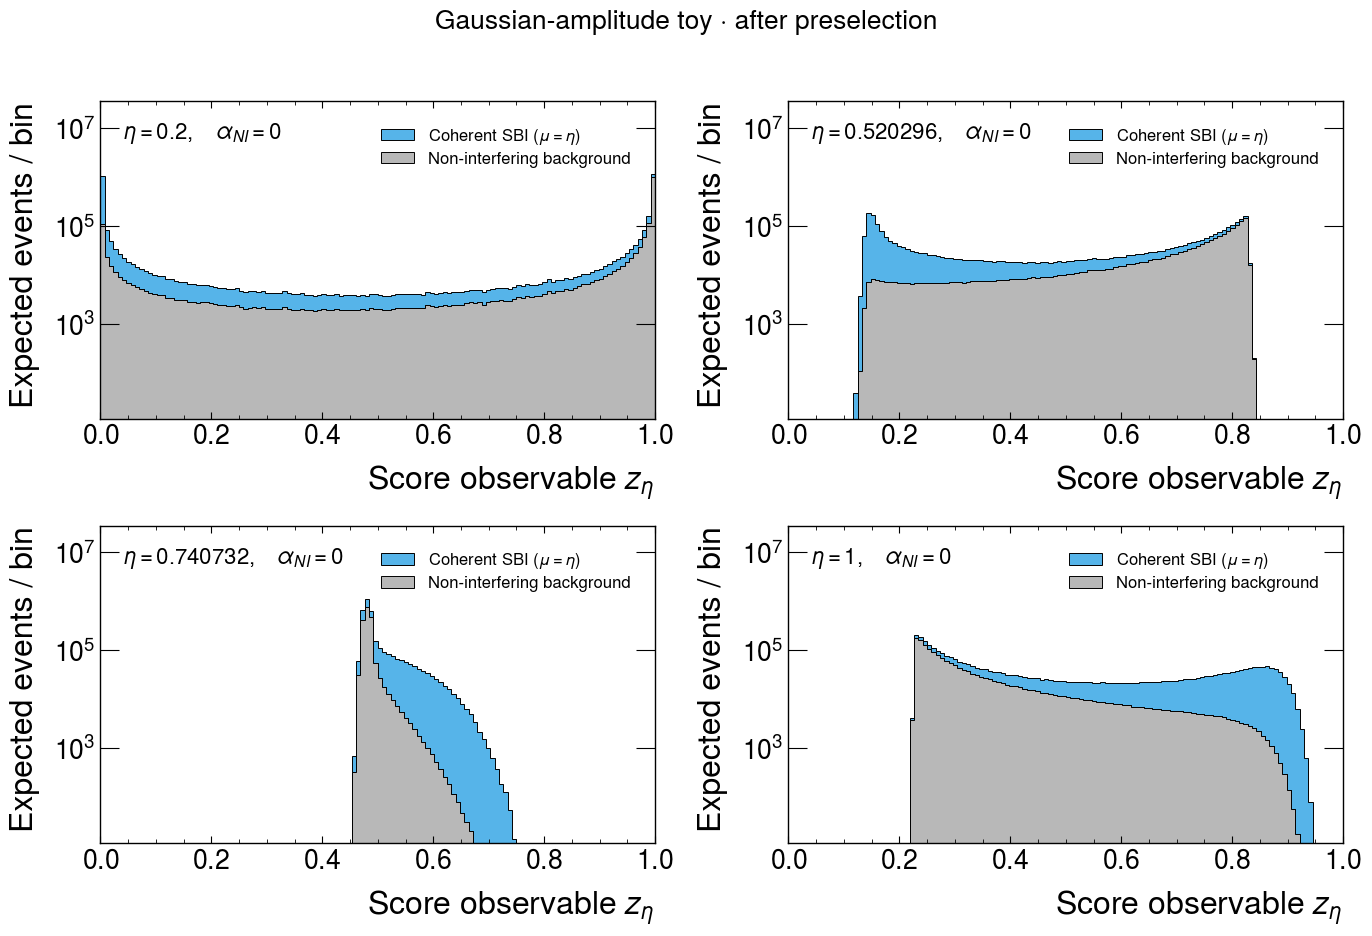

,eta,coherent_SBI_yield,NI_yield,total_yield
0,0.200000,1.714014e+06,1.814532e+06,3.528546e+06
1,0.520296,1.686299e+06,1.814532e+06,3.500832e+06
2,0.740732,1.682748e+06,1.814532e+06,3.497280e+06
3,1.000000,1.686299e+06,1.814532e+06,3.500832e+06


In [3]:
import mplhep as hep
from scipy.special import expit
from poodemo.pipeline import prepare_quadrature, _score
from poodemo.inference import histogram_components

quad = prepare_quadrature(run)
selected_s, selected_sbi, selected_b, _ = quad["nominal"] @ quad["weights"]
rate_kappa = (selected_s + selected_b - selected_sbi) / selected_s
rate_turnover = (rate_kappa / 2)**2 if rate_kappa > 0 else np.nan
other_root = rate_kappa - np.sqrt(run.config["asimov_mu"])
rate_partner = other_root**2 if other_root >= 0 else np.nan
candidate_anchors = [run.config["mu_min"], run.config["asimov_mu"], rate_turnover, rate_partner,
                     (run.config["mu_min"] + run.config["mu_max"]) / 2, run.config["mu_max"]]
ETA_VALUES = []
for anchor in candidate_anchors:
    if (np.isfinite(anchor) and run.config["mu_min"] <= anchor <= run.config["mu_max"]
            and not any(np.isclose(anchor, old) for old in ETA_VALUES)):
        ETA_VALUES.append(float(anchor))
    if len(ETA_VALUES) == 4:
        break
ETA_VALUES = sorted(ETA_VALUES)  # Replace with your own anchors to explore.
HIST_BINS = 128
LOG_Y = True
edges = np.linspace(0., 1., HIST_BINS + 1)
distributions = []
for eta in ETA_VALUES:
    z_eta = expit(_score(run, quad, eta) / run.config["score_scale"])
    # The cached fields already include the process yields (lambda factors).
    nu_s, nu_sbi, nu_b, nu_ni = histogram_components(
        z_eta, quad["nominal"], quad["weights"], edges)
    root_eta = np.sqrt(eta)
    coherent = (eta - root_eta)*nu_s + root_eta*nu_sbi + (1. - root_eta)*nu_b
    tolerance = 1e-12 * max(1., np.max(np.abs(coherent)))
    if np.any(coherent < -tolerance):
        raise ValueError(f"Negative coherent prediction at eta={eta}: {coherent.min()}")
    # Remove only floating-point roundoff after checking positivity.
    distributions.append((eta, np.maximum(coherent, 0.), nu_ni))

with plt.style.context(hep.style.ATLAS), plt.rc_context({"font.size": 16}):
    ncols = min(2, len(distributions))
    nrows = (len(distributions) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 4.8*nrows),
                             sharex=True, sharey=True, squeeze=False)
    ymax = max(np.max(coherent + ni) for _, coherent, ni in distributions)
    for ax, (eta, coherent, ni) in zip(axes.flat, distributions):
        hep.histplot([ni, coherent], bins=edges, stack=True, histtype="fill",
                     color=["#B8B8B8", "#56B4E9"], edgecolor="black", linewidth=0.7,
                     label=["Non-interfering background", r"Coherent SBI ($\mu=\eta$)"],
                     yerr=False, ax=ax)
        ax.text(0.04, 0.94, fr"$\eta={eta:g},\quad\alpha_{{NI}}=0$",
                transform=ax.transAxes, va="top", fontsize=16)
        ax.set(xlim=(0, 1),
               xlabel=r"Score observable $z_\eta$", ylabel="Expected events / bin")
        if LOG_Y:
            ax.set_yscale("log")
            ax.set_ylim(ymax*1e-5, ymax*30)
        else:
            ax.set_ylim(0, 1.45*ymax)
        ax.tick_params(labelbottom=True, labelleft=True)
        ax.grid(False)
        ax.legend(loc="upper right", fontsize=12, frameon=False)
    for ax in axes.flat[len(distributions):]:
        ax.set_visible(False)
    fig.suptitle("Gaussian-amplitude toy · after preselection", fontsize=19)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    (ROOT / "plots").mkdir(exist_ok=True)
    for extension in ("pdf", "png"):
        fig.savefig(ROOT / "plots" / f"04_score_distributions.{extension}",
                    bbox_inches="tight", dpi=160)
    plt.show()

display(pd.DataFrame([
    {"eta": eta, "coherent_SBI_yield": coherent.sum(), "NI_yield": ni.sum(),
     "total_yield": (coherent + ni).sum()}
    for eta, coherent, ni in distributions
]))

### Freeze the observable inside each likelihood fit

For the test of \(\mu_0\), construct \(z_{\eta=\mu_0}\) at nominal
\(\alpha_{NI}=0\), then keep its bin edges, event assignments, and Asimov data
fixed while fitting all physical alternatives \(\mu\). Thus,
\[
t(\mu_0)=-2\log\frac{L(\mu_0;\eta=\mu_0)}
                           {\max_\mu L(\mu;\eta=\mu_0)}.
\]
The Asimov data must also be re-histogrammed when \(\eta\) changes.
The binned likelihood is an independent Poisson likelihood for disjoint
bins of a Poisson point process. This notebook fixes \(\alpha_{NI}=0\),
where the scalar score has its clean local guarantee.

In [4]:
from dataclasses import replace
from poodemo.pipeline import run_binning_study

BIN_COUNTS = np.rint(np.linspace(8, 128, 10)).astype(int).tolist()
# Change only this resolution study; reuse the saved experiment and models.
binning_run = replace(run, config={**run.config, "bin_counts": BIN_COUNTS})
binning = run_binning_study(binning_run)
display(binning['scans'])
display(binning['fidelity'])

Matched eta=0.2: all binnings fitted
Matched eta=0.215: all binnings fitted
Matched eta=0.23: all binnings fitted
Matched eta=0.244: all binnings fitted
Matched eta=0.259: all binnings fitted
Matched eta=0.274: all binnings fitted
Matched eta=0.289: all binnings fitted
Matched eta=0.304: all binnings fitted
Matched eta=0.319: all binnings fitted
Matched eta=0.333: all binnings fitted
Matched eta=0.348: all binnings fitted
Matched eta=0.363: all binnings fitted
Matched eta=0.378: all binnings fitted
Matched eta=0.393: all binnings fitted
Matched eta=0.407: all binnings fitted
Matched eta=0.422: all binnings fitted
Matched eta=0.437: all binnings fitted
Matched eta=0.452: all binnings fitted
Matched eta=0.467: all binnings fitted
Matched eta=0.481: all binnings fitted
Matched eta=0.496: all binnings fitted
Matched eta=0.511: all binnings fitted
Matched eta=0.526: all binnings fitted
Matched eta=0.541: all binnings fitted
Matched eta=0.556: all binnings fitted
Matched eta=0.57: all binnin

,mu,model,systematics,q,valid,mu_hat,alpha_NI,fit_message,eta,n_bins,edm
0,0.200000,direct score histogram,False,287.960958,True,1.0,0.0,No free parameters; Converged bracketed scalar...,0.2,8.0,NaN
1,0.200000,direct score histogram,False,290.415763,True,1.0,0.0,No free parameters; Converged bracketed scalar...,0.2,21.0,NaN
2,0.200000,direct score histogram,False,291.380662,True,1.0,0.0,No free parameters; Converged bracketed scalar...,0.2,35.0,NaN
3,0.200000,direct score histogram,False,291.876790,True,1.0,0.0,No free parameters; Converged bracketed scalar...,0.2,48.0,NaN
4,0.200000,direct score histogram,False,292.214870,True,1.0,0.0,No free parameters; Converged bracketed scalar...,0.2,61.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1061,1.340741,learned unbinned,False,44.473475,True,NaN,0.0,NaN,NaN,NaN,0.0
1062,1.355556,learned unbinned,False,50.814702,True,NaN,0.0,NaN,NaN,NaN,0.0
1063,1.370370,learned unbinned,False,57.680922,True,NaN,0.0,NaN,NaN,NaN,0.0
1064,1.385185,learned unbinned,False,65.089195,True,NaN,0.0,NaN,NaN,NaN,0.0


,eta,n_bins,information_fraction,shape_information_fraction,full_information,binned_information,occupied_bins
0,0.2,8,0.972594,0.904064,11344.612573,11033.701702,8
1,0.2,21,0.982178,0.937615,11344.612573,11142.434457,21
2,0.2,35,0.986047,0.951157,11344.612573,11186.321942,35
3,0.2,48,0.988070,0.958237,11344.612573,11209.266637,48
4,0.2,61,0.989465,0.963123,11344.612573,11225.100158,61
...,...,...,...,...,...,...,...
815,1.4,75,0.999806,0.999395,1040.789248,1040.587321,69
816,1.4,88,0.999852,0.999539,1040.789248,1040.635417,80
817,1.4,101,0.999883,0.999634,1040.789248,1040.667096,92
818,1.4,115,0.999910,0.999718,1040.789248,1040.695245,105


In [5]:
def plot_scans(frame, title, filename, group_columns=None):
    """Plot saved scan tables; adapt grouping to the columns present."""
    x_column = next((c for c in ["mu", "mu_test", "mu0"] if c in frame.columns), None)
    y_column = next((c for c in ["q", "t_mu", "test_statistic", "ts"] if c in frame.columns), None)
    if x_column is None or y_column is None:
        raise ValueError(f"Expected mu and q scan columns; found {list(frame.columns)}")
    if group_columns is None:
        group_columns = [c for c in ["method", "model", "systematics", "nuisances", "n_bins", "bins", "observable"] if c in frame.columns]
    groups = frame.groupby(group_columns, dropna=False, sort=False) if group_columns else [("scan", frame)]
    fig, ax = plt.subplots()
    for label, group in groups:
        group = group.sort_values(x_column)
        values = label if isinstance(label, tuple) else (label,)
        parts = []
        for column, value in zip(group_columns, values):
            if pd.isna(value):
                continue
            if column == "systematics":
                parts.append("profiled" if value else "stat only")
            elif column in ("n_bins", "bins"):
                parts.append(f"{int(value)} bins")
            else:
                parts.append(str(value))
        ax.plot(group[x_column], group[y_column], marker=".", ms=3, label=" | ".join(parts))
    ax.axhline(1.0, color="0.45", ls=":", lw=1)
    ax.set(xlabel=r"Tested signal strength $\mu_0$", ylabel=r"$t(\mu_0)$", title=title)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    fig.tight_layout()
    output = ROOT / "plots"
    output.mkdir(exist_ok=True)
    fig.savefig(output / filename, bbox_inches="tight")
    plt.show()
    return fig

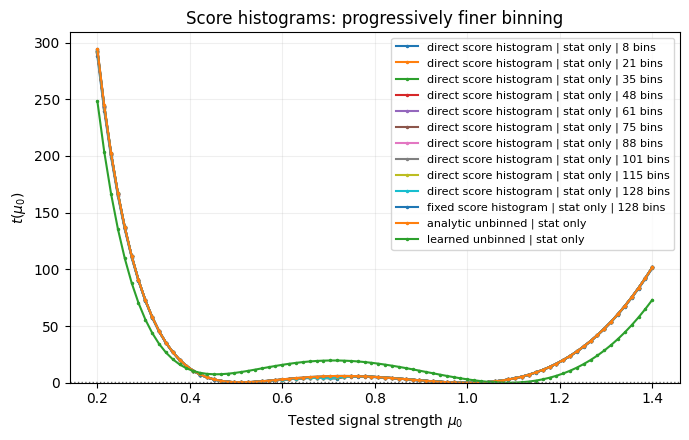

In [6]:
plot_scans(binning['scans'], 'Score histograms: progressively finer binning', '04_binning_scans.pdf');

### What convergence can and cannot show

Two information losses must be distinguished:

1. **Compression** from \(x\) to \(o_\eta\). Before binning, the exact
   score retains the local Fisher information at \(\mu=\eta\).
2. **Finite binning** of that score. At the anchor its shape-information
   loss is \(E_\eta[\operatorname{Var}_\eta(o_\eta\mid\text{bin})]\).

Finer nested bins reduce the second loss. They do not automatically
restore global likelihood information removed by scalar compression.
Consequently, fine-bin curves should approach the **unbinned score
experiment**, and can approximate the full unbinned scan very well
locally; exact equality over a broad interference scan is not guaranteed.
The tables report deviations rather than assuming convergence to zero.

In a fixed generating Asimov experiment, \(\mu_*\) and the tested
\(\eta\) differ away from the minimum. This is precisely where local
optimality must not be mistaken for global sufficiency.

,eta,n_bins,information_fraction,shape_information_fraction,full_information,binned_information,occupied_bins
0,0.2,8,0.972594,0.904064,11344.612573,11033.701702,8
1,0.2,21,0.982178,0.937615,11344.612573,11142.434457,21
2,0.2,35,0.986047,0.951157,11344.612573,11186.321942,35
3,0.2,48,0.988070,0.958237,11344.612573,11209.266637,48
4,0.2,61,0.989465,0.963123,11344.612573,11225.100158,61
...,...,...,...,...,...,...,...
815,1.4,75,0.999806,0.999395,1040.789248,1040.587321,69
816,1.4,88,0.999852,0.999539,1040.789248,1040.635417,80
817,1.4,101,0.999883,0.999634,1040.789248,1040.667096,92
818,1.4,115,0.999910,0.999718,1040.789248,1040.695245,105


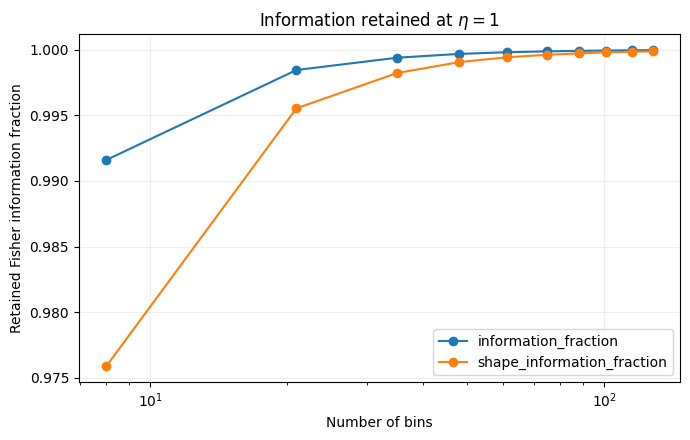

In [7]:
fidelity = binning["fidelity"]
display(fidelity)
eta_near_truth = min(fidelity["eta"].unique(), key=lambda e: abs(e - run.config["asimov_mu"]))
at_anchor = fidelity[np.isclose(fidelity["eta"], eta_near_truth)].sort_values("n_bins")
y_columns = [c for c in fidelity if "information_fraction" in c]
if y_columns:
    ax = at_anchor.plot(x="n_bins", y=y_columns, marker="o", logx=True)
    ax.set(xlabel="Number of bins", ylabel="Retained Fisher information fraction",
           title=fr"Information retained at $\eta={eta_near_truth:.3g}$")
    ax.figure.tight_layout()
    (ROOT / "plots").mkdir(exist_ok=True)
    ax.figure.savefig(ROOT / "plots" / "04_binning_diagnostics.pdf", bbox_inches="tight")
    plt.show()

### Estimator and local uncertainty versus the frozen observable

Now hold the generating experiment fixed at \((\mu_*,\alpha_{NI})=(\mu_*,0)\)
and vary only the observable anchor \(\eta\). Each row refills the
**same Asimov expectation**, freezes that histogram, and fits physical
\(\mu\), with NI either fixed or profiled. For an identified, correctly
modeled Asimov experiment, \(\hat\mu(\eta)\) should remain at the
generating value. This is not a study of finite-sample fluctuations.

The width is evaluated from the local Fisher information at the fixed
truth, using the extended likelihood and the NI auxiliary constraint:
\[
\sigma_\mu^{\rm fixed}(\eta)=1/\sqrt{I_{\mu\mu}^{(\eta)}},\qquad
\sigma_\mu^{\rm profiled}(\eta)
=\sqrt{[(\mathbf I^{(\eta)})^{-1}]_{\mu\mu}}.
\]
This is the local Asimov curvature of **each frozen-observable fit**.
It is neither the curvature of the scan that changes \(\eta=\mu_0\)
at every point nor a global confidence interval. A second likelihood
minimum can produce additional accepted parameter regions that a local
width cannot describe.

The full unbinned reference does not depend on \(\eta\). For the binned
comparison, profiled widths use nuisance morphing after binning, as in
notebook 5; its difference from integrating the unbinned morphing is a
separate model effect. Inspect anomalous fitted values for optimizer
failure or multiple equally good minima before interpreting them as
compression bias.

In [8]:
from poodemo.diagnostics import run_estimator_study

estimator_study = run_estimator_study(run)
display(estimator_study)
invalid_rows = estimator_study[~estimator_study["fit_valid"] | ~estimator_study["width_valid"]]
if len(invalid_rows):
    print("Invalid fits or local widths (omitted from the corresponding curves):")
    display(invalid_rows)
print("Saved estimator table:", ROOT / "results" / "estimator_eta.csv")

Estimator and local-width study at eta=0.2 ready
Estimator and local-width study at eta=0.215 ready
Estimator and local-width study at eta=0.23 ready
Estimator and local-width study at eta=0.244 ready
Estimator and local-width study at eta=0.259 ready
Estimator and local-width study at eta=0.274 ready
Estimator and local-width study at eta=0.289 ready
Estimator and local-width study at eta=0.304 ready
Estimator and local-width study at eta=0.319 ready
Estimator and local-width study at eta=0.333 ready
Estimator and local-width study at eta=0.348 ready
Estimator and local-width study at eta=0.363 ready
Estimator and local-width study at eta=0.378 ready
Estimator and local-width study at eta=0.393 ready
Estimator and local-width study at eta=0.407 ready
Estimator and local-width study at eta=0.422 ready
Estimator and local-width study at eta=0.437 ready
Estimator and local-width study at eta=0.452 ready
Estimator and local-width study at eta=0.467 ready
Estimator and local-width study at

,eta,model,n_bins,morph_order,truth,information_mu,mu_hat,mu_hat_minus_truth,alpha_NI_hat,systematics,...,rate_information_mu_mu,shape_information_mu_mu,expected_events,nuisance_derivative_relative_error,width_method,information_mu_effective,sigma_mu,width_valid,width_message,valid
0,0.200000,direct score histogram,512,after,1.0,1.0,1.0,0.000000e+00,0.000000e+00,False,...,185.555339,96.560795,3.500832e+06,6.107165e-11,Fisher/Asimov local curvature at fixed generat...,282.116134,0.059537,True,Local Fisher/Asimov width,True
1,0.200000,analytic unbinned,0,unbinned,1.0,1.0,1.0,0.000000e+00,0.000000e+00,False,...,185.555339,99.371536,3.500832e+06,5.214218e-11,Fisher/Asimov local curvature at fixed generat...,284.926875,0.059242,True,Local Fisher/Asimov width,True
2,0.200000,direct score histogram,512,after,1.0,1.0,1.0,6.585319e-08,-6.464263e-09,True,...,185.555339,96.560795,3.500832e+06,6.107165e-11,Fisher/Asimov local curvature at fixed generat...,210.995152,0.068844,True,Local Fisher/Asimov width,True
3,0.200000,analytic unbinned,0,unbinned,1.0,1.0,1.0,0.000000e+00,0.000000e+00,True,...,185.555339,99.371536,3.500832e+06,5.214218e-11,Fisher/Asimov local curvature at fixed generat...,217.266726,0.067843,True,Local Fisher/Asimov width,True
4,0.214815,direct score histogram,512,after,1.0,1.0,1.0,0.000000e+00,0.000000e+00,False,...,185.555339,97.126305,3.500832e+06,6.879888e-11,Fisher/Asimov local curvature at fixed generat...,282.681644,0.059477,True,Local Fisher/Asimov width,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,1.385185,analytic unbinned,0,unbinned,1.0,1.0,1.0,0.000000e+00,0.000000e+00,True,...,185.555339,99.371536,3.500832e+06,5.214218e-11,Fisher/Asimov local curvature at fixed generat...,217.266726,0.067843,True,Local Fisher/Asimov width,True
324,1.400000,direct score histogram,512,after,1.0,1.0,1.0,0.000000e+00,0.000000e+00,False,...,185.555339,99.352165,3.500832e+06,4.508682e-11,Fisher/Asimov local curvature at fixed generat...,284.907504,0.059245,True,Local Fisher/Asimov width,True
325,1.400000,analytic unbinned,0,unbinned,1.0,1.0,1.0,0.000000e+00,0.000000e+00,False,...,185.555339,99.371536,3.500832e+06,5.214218e-11,Fisher/Asimov local curvature at fixed generat...,284.926875,0.059242,True,Local Fisher/Asimov width,True
326,1.400000,direct score histogram,512,after,1.0,1.0,1.0,9.319867e-08,-3.120360e-09,True,...,185.555339,99.352165,3.500832e+06,4.508682e-11,Fisher/Asimov local curvature at fixed generat...,216.001683,0.068041,True,Local Fisher/Asimov width,True


Saved estimator table: /content/drive/MyDrive/poodemo/runs/paper-nearby-v2/results/estimator_eta.csv


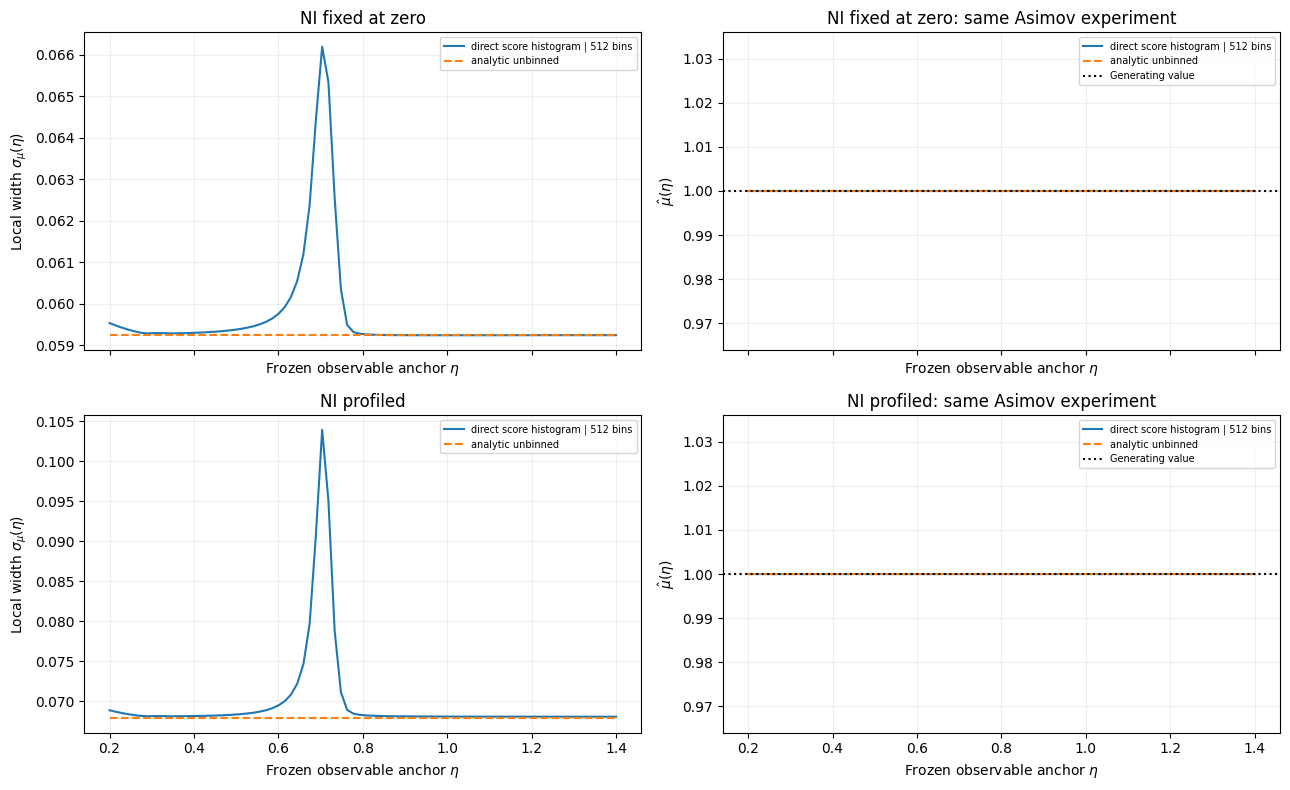

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, squeeze=False)
truth_mu = float(estimator_study["truth"].iloc[0])
for row, systematic in enumerate([False, True]):
    subset = estimator_study[estimator_study["systematics"] == systematic]
    group_columns = [c for c in ["model", "n_bins"] if c in subset.columns]
    for label, values in subset.groupby(group_columns, dropna=False, sort=False):
        values = values.sort_values("eta")
        label_values = label if isinstance(label, tuple) else (label,)
        parts = [f"{int(value)} bins" if name == "n_bins" else str(value)
                 for name, value in zip(group_columns, label_values)
                 if pd.notna(value) and (name != "n_bins" or float(value) > 0)]
        legend_label = " | ".join(parts)
        line_style = "--" if "unbinned" in str(label_values[0]).lower() else "-"
        sigma = values["sigma_mu"].replace([np.inf, -np.inf], np.nan).where(values["width_valid"])
        axes[row, 0].plot(values["eta"], sigma, line_style, label=legend_label)
        axes[row, 1].plot(values["eta"], values["mu_hat"].where(values["fit_valid"]), line_style, label=legend_label)
    nuisance_label = "NI profiled" if systematic else "NI fixed at zero"
    axes[row, 0].set(title=nuisance_label, ylabel=r"Local width $\sigma_\mu(\eta)$")
    axes[row, 1].axhline(truth_mu, color="black", ls=":", label="Generating value")
    axes[row, 1].set(title=nuisance_label + ": same Asimov experiment", ylabel=r"$\hat\mu(\eta)$")
    finite_estimates = subset.loc[subset["fit_valid"], "mu_hat"].to_numpy()
    finite_estimates = finite_estimates[np.isfinite(finite_estimates)]
    lower = min(truth_mu, finite_estimates.min()) if len(finite_estimates) else truth_mu
    upper = max(truth_mu, finite_estimates.max()) if len(finite_estimates) else truth_mu
    margin = max(.03 * (run.config["mu_max"] - run.config["mu_min"]), .1 * (upper - lower))
    axes[row, 1].set_ylim(lower - margin, upper + margin)
    for ax in axes[row]:
        ax.set_xlabel(r"Frozen observable anchor $\eta$")
        ax.legend(fontsize=7)
fig.tight_layout()
for extension in ("pdf", "png"):
    fig.savefig(ROOT / "plots" / f"04_estimator_eta.{extension}", bbox_inches="tight", dpi=160)
plt.show()

Next: **05_spline_templates.ipynb**.